In [1]:

%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from wrf_io import *
from scipy.io import savemat
from MITRotor import IEA10MW
from itertools import product
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler

## Train data

In [3]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'

In [4]:
casenames = [
r'sn030_vn200',
r'sn030_vn100',
r'sn030_vn050',
r'sn030_vn025',
r'sn030_v000',
r'sn030_v025',
r'sn030_v050',
r'sn030_v100',
r'sn030_v200',
r'sn020_vn200',
r'sn020_vn100',
r'sn020_vn050',
r'sn020_vn025',
r'sn020_v000',
r'sn020_v025',
r'sn020_v050',
r'sn020_v100',
r'sn020_v200',
r'sn010_vn200',
r'sn010_vn100',
r'sn010_vn050',
r'sn010_vn025',
r'sn010_v000',
r'sn010_v025',
r'sn010_v050',
r'sn010_v100',
r'sn010_v200',
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200',
r's010_vn200',
r's010_vn100',
r's010_vn050',
r's010_vn025',
r's010_v000',
r's010_v025',
r's010_v050',
r's010_v100',
r's010_v200',
r's020_vn200',
r's020_vn100',
r's020_vn050',
r's020_vn025',
r's020_v000',
r's020_v025',
r's020_v050',
r's020_v100',
r's020_v200',
r's030_vn200',
r's030_vn100',
r's030_vn050',
r's030_vn025',
r's030_v000',
r's030_v025',
r's030_v050',
r's030_v100',
r's030_v200'
]

In [5]:
casenames = [
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200'
]

In [6]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/parameters.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [7]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [8]:
cases = [pair for pair in product(params['shear'], params['veer'])]
shears = [pair[0] for pair in cases]
veers = [pair[1] for pair in cases]

shears = np.array(shears)  
veers  = np.array(veers)

In [18]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_U_inf    = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_wdir_inf = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_U        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_wdir     = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_cax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

shapiro      = np.zeros(len(casenames), dtype=float)

Uhub         = np.zeros(len(casenames), dtype=float)

wrf_tsr      = np.zeros(len(casenames), dtype=float)
wrf_omg      = np.zeros(len(casenames), dtype=float)

wrf_cot_rot  = np.zeros(len(casenames), dtype=float)
wrf_ind_rot  = np.zeros(len(casenames), dtype=float)

r_ann        = np.zeros((Nelm, len(casenames)),dtype='longdouble')
shears_ann   = np.zeros((Nelm, len(casenames)),dtype='longdouble')
veers_ann    = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_ann  = np.zeros((Nelm, len(casenames)),dtype='longdouble')
wrf_ind_ann  = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_loc  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_ind_loc  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    U_inf = np.sqrt(u_inf**2 + v_inf**2).T

    wdir_inf = np.atan2(v_inf,u_inf).T

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    # v_rotor_full = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # v_rotor = v_rotor_full - v_inf

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)
    U_hub = np.sqrt(u_inf**2 + v_inf**2).T

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtn

    wrf_vax_real[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi[:,:,count]      = phi
    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W[:,:,count]        = W
    wrf_W_real[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax[:,:,count]      = Cax

    wrf_cot_rot[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind_rot[count]      = postproc.rotor_average(1 - u_rotor/ u_inf.T,r,theta)

    wrf_cot_ann[:,count]    = postproc.annulus_average(ct,theta)
    wrf_ind_ann[:,count]    = postproc.annulus_average(1 - u_rotor/ U_hub,theta)

    r_ann[:,count]          = r
    shears_ann[:,count]     = shears[count] * np.ones_like(r)
    veers_ann[:,count]      = veers[count] * np.ones_like(r)

    wrf_cot_loc[:,:,count]  = ct
    wrf_ind_loc[:,:,count]  = 1 - u_rotor/ U_hub

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L[:,:,count]        = L
    wrf_D[:,:,count]        = D

    wrf_L_real[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN[:,:,count]       = FN
    wrf_FT[:,:,count]       = FT

    wrf_FN_real[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr[count]          = T
    wrf_pow[count]          = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    # Uhub[count]             = U_hub
    # wrf_tsr[count]          = tsr
    # wrf_omg[count]          = omega[0]

    # wrf_U_inf[:,:,count]    = U_inf
    # wrf_wdir_inf[:,:,count] = wdir_inf
    
    # wrf_U[:,:,count]        = U
    # wrf_wdir[:,:,count]     = wdir

# END LOOP

process_path = '/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/'

# np.save(process_path + 'sweep_names.npy', casenames)
# np.save(process_path + 'U_loc.npy', wrf_U_inf)
# np.save(process_path + 'dir_loc.npy', wrf_wdir_inf)
# np.save(process_path + 'U_disk.npy', wrf_U)
# np.save(process_path + 'dir_disk.npy', wrf_wdir)
# np.save(process_path + 'Uhub.npy', Uhub)
# np.save(process_path + 'wrf_tsr.npy', wrf_tsr)
# np.save(process_path + 'wrf_omg.npy', wrf_omg)
# np.savez(process_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

# np.save(save_path + 'wrf_cot_loc.npy', wrf_cot_loc)
# np.save(save_path + 'wrf_ind_loc.npy', wrf_ind_loc)

# np.save(save_path + 'wrf_cot_ann.npy', wrf_cot_ann)
# np.save(save_path + 'wrf_ind_ann.npy', wrf_ind_ann)

# np.save(save_path + 'wrf_cot_rot.npy', wrf_cot_rot)
# np.save(save_path + 'wrf_ind_rot.npy', wrf_ind_rot)
# np.savez(save_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

In [20]:
wrf_ind_rot

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.24985269,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])

In [19]:
wrf_cot_rot

array([0.65595863, 0.67518997, 0.68134433, 0.68336551, 0.6846248 ,
       0.68508567, 0.68475143, 0.68174277, 0.66750667])

# Additional points around origin

In [151]:
casenames = [
r'sn0025_vn0100',
r'sn0025_vn0250',
r'sn0025_v0000',
r'sn0025_v0250',
r'sn0025_v0100',
r's0025_vn0100',
r's0025_vn0250',
r's0025_v0000',
r's0025_v0250',
r's0025_v0100'
]

In [152]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/new_origin_train/gad_sweep/opt_params.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /home1/09909/smata/dir_scratch/wrf_les_sweep/runs/10MW/rate/new_origin_train
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.0025, 0, 0.0025]
veer           : [-0.01, -0.025, 0, 0.025, 0.01]
excluded_pairs : [(0, 0.01), (0, 0.025), (0, 0), (0, -0.025), (0, -0.01)]
Ufst           : 7


In [153]:
# cases = [pair for pair in product(params['shear'], params['veer'])]

exclude = params['excluded_pairs']
cases = [
    pair for pair in product(params['shear'], params['veer'])
    if pair not in exclude
]

shears_not = [pair[0] for pair in cases]
veers_not = [pair[1] for pair in cases]

shears_not = np.array(shears_not)  
veers_not  = np.array(veers_not)

In [ ]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax_not      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_not      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real_not = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real_not = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR_not   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real_not= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_U_inf_not    = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_wdir_inf_not = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_U_not        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_wdir_not     = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W_not        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real_not   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_not       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_not       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_not       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_not        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real_not   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_not       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_not       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi_not      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real_not = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa_not      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real_not = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_cax_not      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow_not      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_not      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real_not = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real_not = np.zeros(len(casenames),dtype='longdouble')

shapiro_not      = np.zeros(len(casenames), dtype=float)

Uhub_not         = np.zeros(len(casenames), dtype=float)

wrf_tsr_not      = np.zeros(len(casenames), dtype=float)
wrf_omg_not      = np.zeros(len(casenames), dtype=float)

wrf_cot_rot_not  = np.zeros(len(casenames), dtype=float)
wrf_ind_rot_not  = np.zeros(len(casenames), dtype=float)

r_ann_not        = np.zeros((Nelm, len(casenames)),dtype='longdouble')
shears_ann_not   = np.zeros((Nelm, len(casenames)),dtype='double')
veers_ann_not    = np.zeros((Nelm, len(casenames)),dtype='double')

wrf_cot_ann_not  = np.zeros((Nelm, len(casenames)),dtype='longdouble')
wrf_ind_ann_not  = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_loc_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_ind_loc_not  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    U_inf = np.sqrt(u_inf**2 + v_inf**2).T

    wdir_inf = np.atan2(v_inf,u_inf).T

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    # v_rotor_full = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # v_rotor = v_rotor_full - v_inf

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax_not[:,:,count]      = Vax
    wrf_vtn_not[:,:,count]      = Vtn

    wrf_vax_real_not[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real_not[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR_not[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real_not[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi_not[:,:,count]      = phi
    wrf_phi_real_not[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa_not[:,:,count]      = aoa
    wrf_aoa_real_not[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W_not[:,:,count]        = W
    wrf_W_real_not[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax_not[:,:,count]      = Cax

    wrf_cot_rot_not[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind_rot_not[count]      = postproc.rotor_average(1 - u_rotor/ U_hub,r,theta)

    wrf_cot_ann_not[:,count]    = postproc.annulus_average(ct,theta)
    wrf_ind_ann_not[:,count]    = postproc.annulus_average(1 - u_rotor/ U_hub,theta)

    r_ann_not[:,count]          = r
    shears_ann_not[:,count]     = shears_not[count] * np.ones_like(r)
    veers_ann_not[:,count]      = veers_not[count] * np.ones_like(r)

    wrf_cot_loc_not[:,:,count]  = ct
    wrf_ind_loc_not[:,:,count]  = 1 - u_rotor/ U_hub

    wrf_CL_not[:,:,count]       = Cl
    wrf_CD_not[:,:,count]       = Cd

    wrf_CL_real_not[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real_not[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L_not[:,:,count]        = L
    wrf_D_not[:,:,count]        = D

    wrf_L_real_not[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real_not[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN_not[:,:,count]       = FN
    wrf_FT_not[:,:,count]       = FT

    wrf_FN_real_not[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real_not[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr_not[count]          = T
    wrf_pow_not[count]          = P

    wrf_thr_real_not[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real_not[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    Uhub_not[count]             = U_hub
    wrf_tsr_not[count]          = tsr
    wrf_omg_not[count]          = omega[0]

    wrf_U_inf_not[:,:,count]    = U_inf
    wrf_wdir_inf_not[:,:,count] = wdir_inf
    
    wrf_U_not[:,:,count]        = U
    wrf_wdir_not[:,:,count]     = wdir

# END LOOP

process_path = '/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/'

# np.save(process_path + 'sweep_names.npy', casenames)
# np.save(process_path + 'U_loc.npy', wrf_U_inf)
# np.save(process_path + 'dir_loc.npy', wrf_wdir_inf)
# np.save(process_path + 'U_disk.npy', wrf_U)
# np.save(process_path + 'dir_disk.npy', wrf_wdir)
# np.save(process_path + 'Uhub.npy', Uhub)
# np.save(process_path + 'wrf_tsr.npy', wrf_tsr)
# np.save(process_path + 'wrf_omg.npy', wrf_omg)
# np.savez(process_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

# np.save(save_path + 'wrf_cot_loc.npy', wrf_cot_loc)
# np.save(save_path + 'wrf_ind_loc.npy', wrf_ind_loc)

# np.save(save_path + 'wrf_cot_ann.npy', wrf_cot_ann)
# np.save(save_path + 'wrf_ind_ann.npy', wrf_ind_ann)

# np.save(save_path + 'wrf_cot_rot.npy', wrf_cot_rot)
# np.save(save_path + 'wrf_ind_rot.npy', wrf_ind_rot)
# np.savez(save_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

In [156]:
r_ann       = np.column_stack([r_ann, r_ann_not])
wrf_cot_loc = np.concatenate([wrf_cot_loc,wrf_cot_loc_not],axis=2)
wrf_ind_loc = np.concatenate([wrf_ind_loc,wrf_ind_loc_not],axis=2)
wrf_cot_ann = np.concatenate([wrf_cot_ann,wrf_cot_ann_not],axis=1)
wrf_ind_ann = np.concatenate([wrf_ind_ann,wrf_ind_ann_not],axis=1)
wrf_cot_rot = np.concatenate([wrf_cot_rot,wrf_cot_rot_not])
wrf_ind_rot = np.concatenate([wrf_ind_rot,wrf_ind_rot_not])
shears      = np.concatenate([shears,shears_not])
veers       = np.concatenate([veers,veers_not])
shears_ann  = np.concatenate([shears_ann,shears_ann_not],axis=1)
veers_ann   = np.concatenate([veers_ann,veers_ann_not],axis=1)

In [157]:
# Create a list of (name, array) pairs
variables = [
    ('r_ann'      , r_ann),
    ('wrf_cot_loc', wrf_cot_loc),
    ('wrf_ind_loc', wrf_ind_loc),
    ('wrf_cot_ann', wrf_cot_ann),
    ('wrf_ind_ann', wrf_ind_ann),
    ('wrf_cot_rot', wrf_cot_rot),
    ('wrf_ind_rot', wrf_ind_rot),
    ('shears'     , shears),
    ('veers'      , veers),
    ('shears_ann' , shears_ann),
    ('veers_ann'  , veers_ann),
]

# Print descriptive statistics
print("Variable Statistics:")
print("-" * 75)
print(f"{'Name':<15} | {'Mean':>8} | {'Std Dev':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 75)

for name, arr in variables:
    arr_flat = arr.flatten()
    mean = np.mean(arr_flat)
    std = np.std(arr_flat)
    min_val = np.min(arr_flat)
    max_val = np.max(arr_flat)
    print(f"{name:<15} | {mean:>8.4f} | {std:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

Variable Statistics:
---------------------------------------------------------------------------
Name            |     Mean |  Std Dev |      Min |      Max
---------------------------------------------------------------------------
r_ann           |   0.5121 |   0.2815 |   0.0429 |   0.9812
wrf_cot_loc     |   0.7114 |   0.3082 |   0.0733 |   1.1959
wrf_ind_loc     |   0.2399 |   0.1488 |  -0.3718 |   0.6396
wrf_cot_ann     |   0.7114 |   0.3002 |   0.1031 |   1.0409
wrf_ind_ann     |   0.2399 |   0.1089 |  -0.0072 |   0.3579
wrf_cot_rot     |   0.6869 |   0.0064 |   0.6705 |   0.7022
wrf_ind_rot     |   0.2447 |   0.0095 |   0.2218 |   0.2676
shears          |  -0.0000 |   0.0186 |  -0.0300 |   0.0300
veers           |  -0.0000 |   0.1011 |  -0.2000 |   0.2000
shears_ann      |   0.0000 |   0.0186 |  -0.0300 |   0.0300
veers_ann       |   0.0000 |   0.1011 |  -0.2000 |   0.2000


In [158]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann_RAW.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot_RAW.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

In [159]:
from sklearn.preprocessing import OneHotEncoder

# Regime encoding legend:
# 0 - Uniform flow (no shear, no veer)
# 1 - Veer only (shear == 0, veer != 0)
# 2 - Shear only (shear != 0, veer == 0)
# 3 - Shear and veer (shear != 0, veer != 0)

# Define categorical regimes
regimes = (
    (shears_ann.flatten() != 0).astype(int) * 2 + (veers_ann.flatten() != 0).astype(int)
).reshape(-1, 1)  # gives 0 to 3

# One-hot encode
encoder = OneHotEncoder(sparse_output=False)
regime_onehot = encoder.fit_transform(regimes)  # shape (N, 4)
regime_onehot

array([[0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], shape=(1898, 4))

In [160]:
# ── standardize every array, overwriting in place ──────────────────────────────
# 1-D (_rot) -------------------------------------------------------------------
scaler_wrf_cot_rot = StandardScaler()
wrf_cot_rot = scaler_wrf_cot_rot.fit_transform(wrf_cot_rot[:, None]).ravel()

scaler_wrf_ind_rot = StandardScaler()
wrf_ind_rot = scaler_wrf_ind_rot.fit_transform(wrf_ind_rot[:, None]).ravel()

scaler_shears = StandardScaler()
shears = scaler_shears.fit_transform(shears[:, None]).ravel()

scaler_veers = StandardScaler()
veers = scaler_veers.fit_transform(veers[:, None]).ravel()

# 2-D (_ann) -------------------------------------------------------------------
scaler_wrf_cot_ann = StandardScaler()
wrf_cot_ann = scaler_wrf_cot_ann.fit_transform(wrf_cot_ann.flatten()[:, None]) \
                                .reshape(wrf_cot_ann.shape)

scaler_wrf_ind_ann = StandardScaler()
wrf_ind_ann = scaler_wrf_ind_ann.fit_transform(wrf_ind_ann.flatten()[:, None]) \
                                .reshape(wrf_ind_ann.shape)

scaler_shears_ann = StandardScaler()
shears_ann = scaler_shears_ann.fit_transform(shears_ann.flatten()[:, None]) \
                              .reshape(shears_ann.shape)

scaler_veers_ann = StandardScaler()
veers_ann = scaler_veers_ann.fit_transform(veers_ann.flatten()[:, None]) \
                            .reshape(veers_ann.shape)

In [161]:
# Create a list of (name, array) pairs
variables = [
    ('r_ann'      , r_ann),
    ('wrf_cot_loc', wrf_cot_loc),
    ('wrf_ind_loc', wrf_ind_loc),
    ('wrf_cot_ann', wrf_cot_ann),
    ('wrf_ind_ann', wrf_ind_ann),
    ('wrf_cot_rot', wrf_cot_rot),
    ('wrf_ind_rot', wrf_ind_rot),
    ('shears'     , shears),
    ('veers'      , veers),
    ('shears_ann' , shears_ann),
    ('veers_ann'  , veers_ann),
]

# Print descriptive statistics
print("Variable Statistics:")
print("-" * 75)
print(f"{'Name':<15} | {'Mean':>8} | {'Std Dev':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 75)

for name, arr in variables:
    arr_flat = arr.flatten()
    mean = np.mean(arr_flat)
    std = np.std(arr_flat)
    min_val = np.min(arr_flat)
    max_val = np.max(arr_flat)
    print(f"{name:<15} | {mean:>8.4f} | {std:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

Variable Statistics:
---------------------------------------------------------------------------
Name            |     Mean |  Std Dev |      Min |      Max
---------------------------------------------------------------------------
r_ann           |   0.5121 |   0.2815 |   0.0429 |   0.9812
wrf_cot_loc     |   0.7114 |   0.3082 |   0.0733 |   1.1959
wrf_ind_loc     |   0.2399 |   0.1488 |  -0.3718 |   0.6396
wrf_cot_ann     |  -0.0000 |   1.0000 |  -2.0264 |   1.0975
wrf_ind_ann     |   0.0000 |   1.0000 |  -2.2695 |   1.0840
wrf_cot_rot     |  -0.0000 |   1.0000 |  -2.5544 |   2.3728
wrf_ind_rot     |  -0.0000 |   1.0000 |  -2.3969 |   2.3994
shears          |   0.0000 |   1.0000 |  -1.6127 |   1.6127
veers           |   0.0000 |   1.0000 |  -1.9776 |   1.9776
shears_ann      |   0.0000 |   1.0000 |  -1.6127 |   1.6127
veers_ann       |  -0.0000 |   1.0000 |  -1.9776 |   1.9776


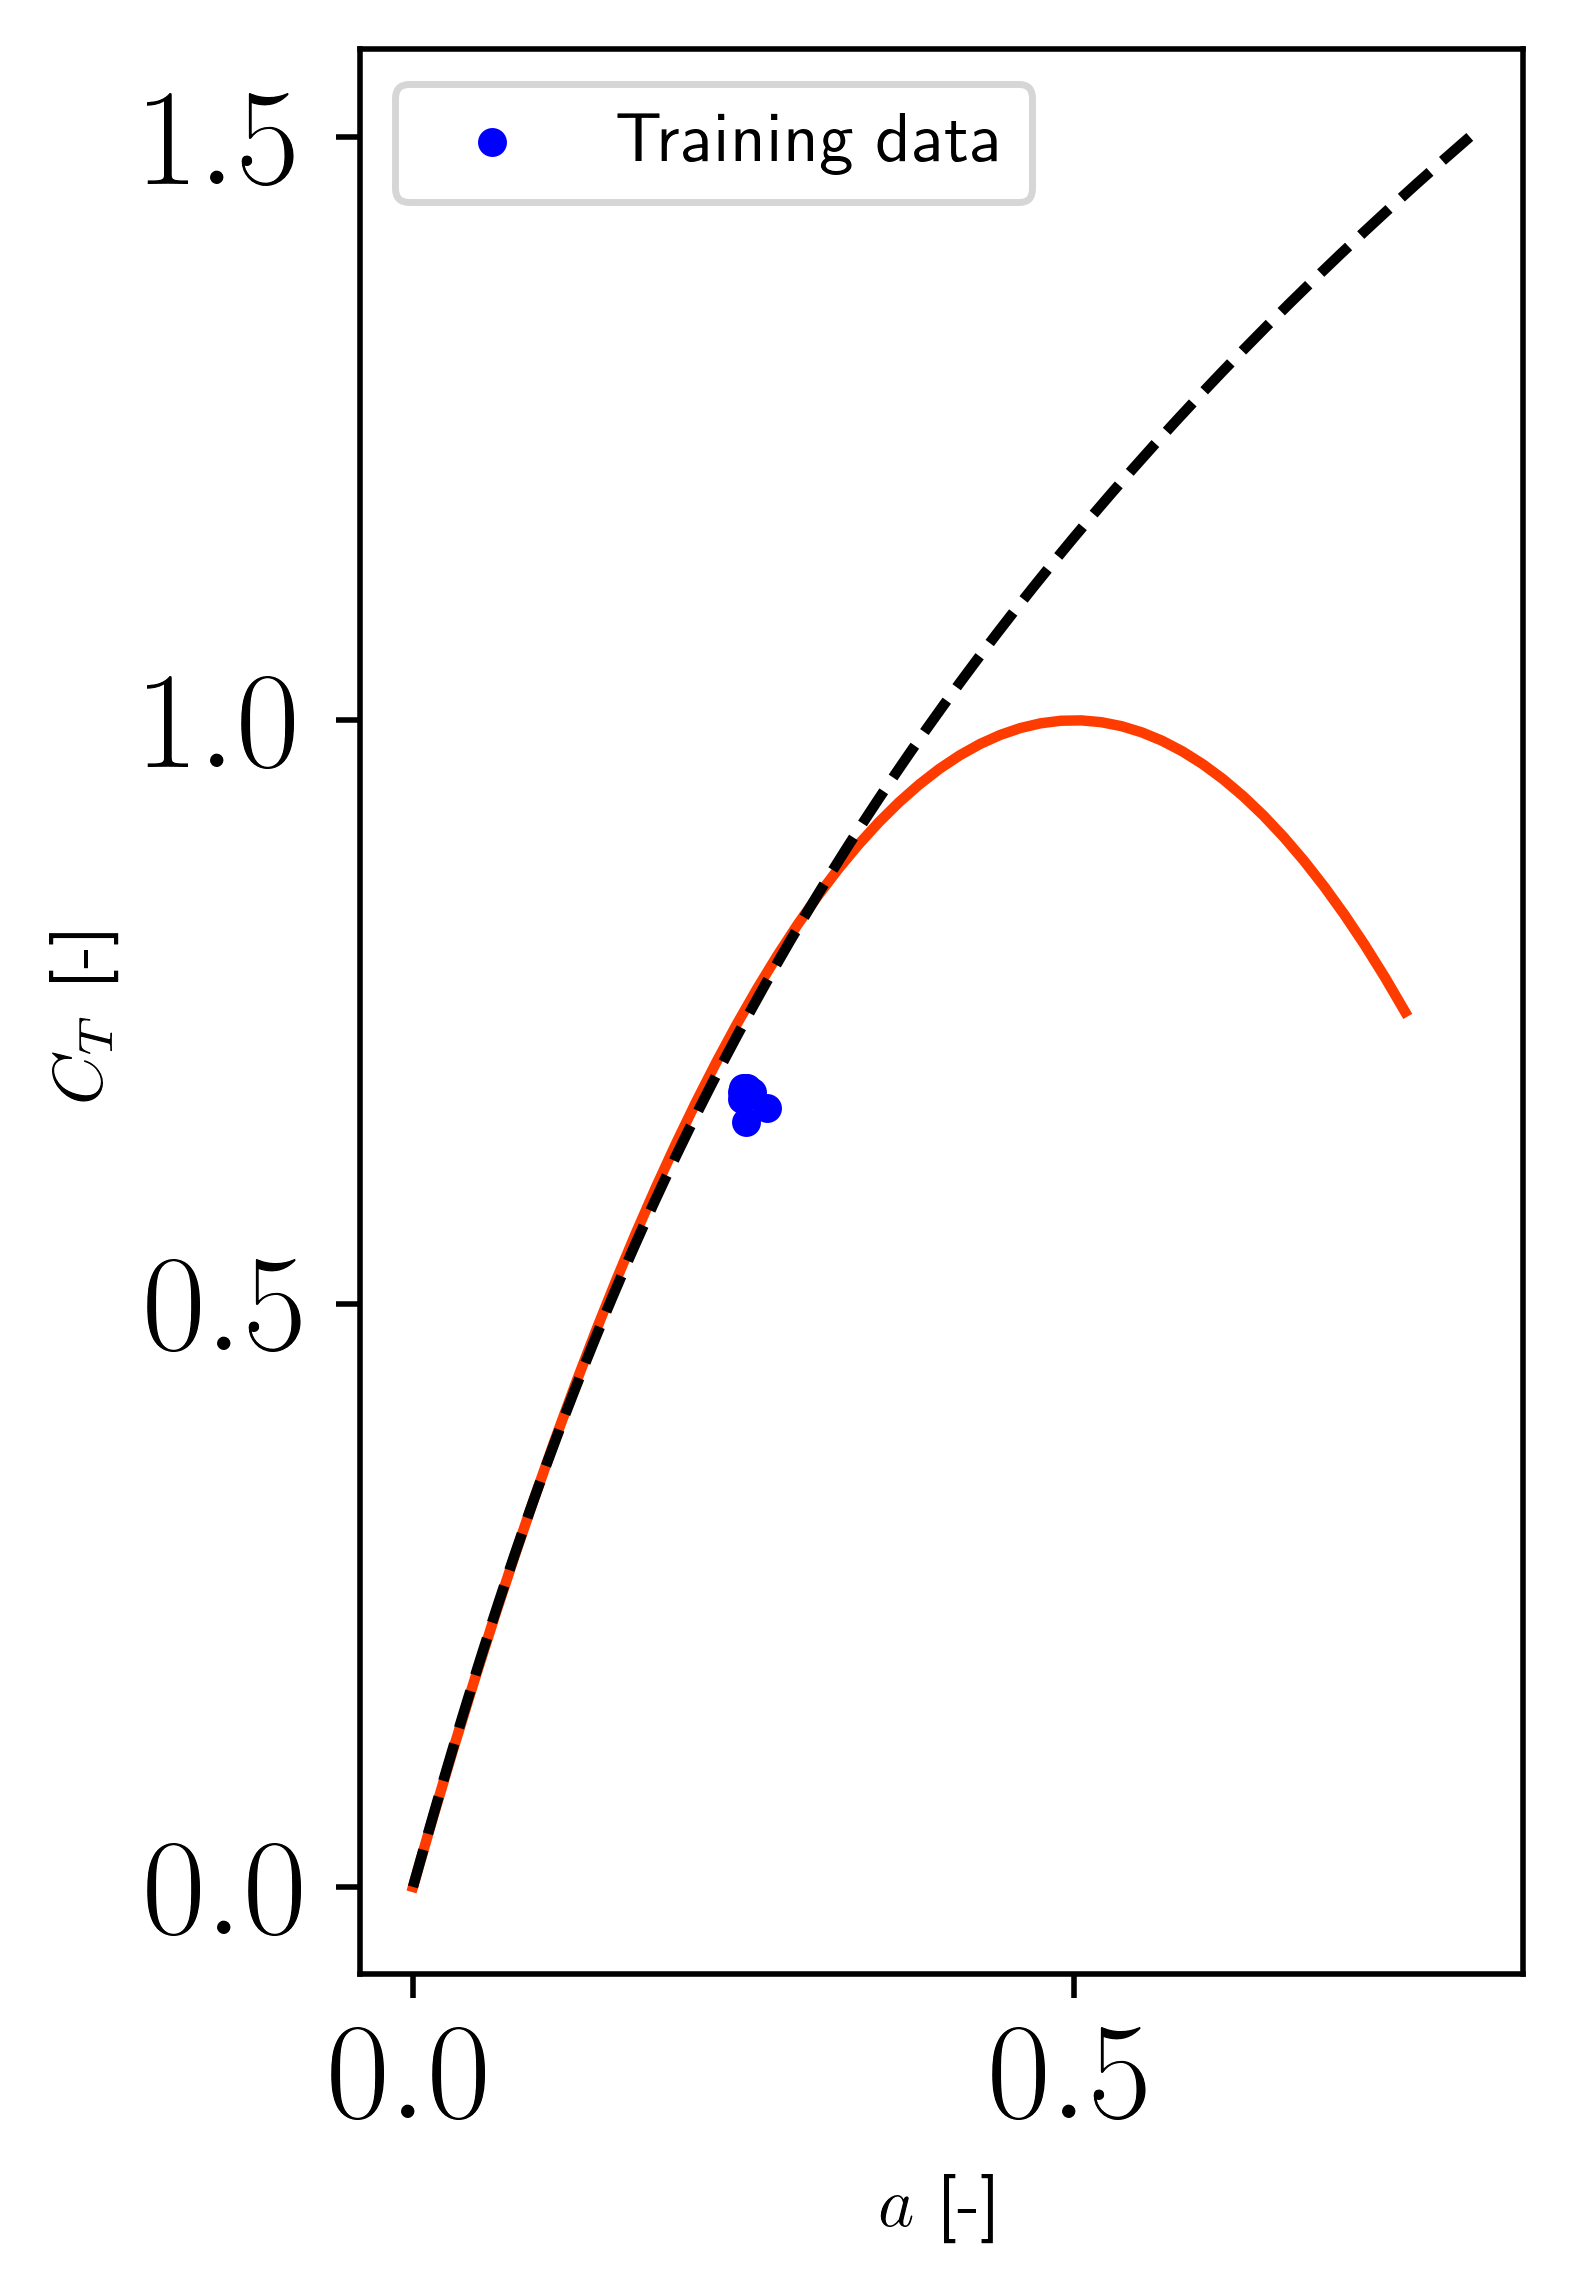

In [24]:

index = 31

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 5))

# ct_recond = scaler_wrf_cot_ann.inverse_transform(wrf_cot_rot.reshape(-1,1)).ravel()
# a_recond = scaler_wrf_ind_ann.inverse_transform(wrf_ind_rot.reshape(-1,1)).ravel()

ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
ax.plot(a_mad,ct_mad,'k--',zorder=1)
ax.scatter(wrf_ind_rot,wrf_cot_rot,10,color='b',label='Training data')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

ax.legend()

In [162]:
# Save scalers

with open(os.path.join(save_path, 'scaler_wrf_cot_ann.pkl'), 'wb') as f:
    pickle.dump(scaler_wrf_cot_ann, f)

with open(os.path.join(save_path, 'scaler_wrf_ind_ann.pkl'), 'wb') as f:
    pickle.dump(scaler_wrf_ind_ann, f)

with open(os.path.join(save_path, 'scaler_wrf_cot_rot.pkl'), 'wb') as f:
    pickle.dump(scaler_wrf_cot_rot, f)

with open(os.path.join(save_path, 'scaler_wrf_ind_rot.pkl'), 'wb') as f:
    pickle.dump(scaler_wrf_ind_rot, f)

with open(os.path.join(save_path, 'scaler_shears_rot.pkl'), 'wb') as f:
    pickle.dump(scaler_shears, f)

with open(os.path.join(save_path, 'scaler_veers_rot.pkl'), 'wb') as f:
    pickle.dump(scaler_veers, f)

with open(os.path.join(save_path, 'scaler_shears_ann.pkl'), 'wb') as f:
    pickle.dump(scaler_shears_ann, f)

with open(os.path.join(save_path, 'scaler_veers_ann.pkl'), 'wb') as f:
    pickle.dump(scaler_veers_ann, f)

In [163]:
# Generate MATLAB inputs for GP search

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

## Validation data

In [164]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/'

In [ ]:
casenames = [
r'sn0300_vn2500',
r'sn0300_vn1500',
r'sn0300_vn0750',
r'sn0300_vn0350',
r'sn0300_v0350',
r'sn0300_v0750',
r'sn0300_v1500',
r'sn0300_v2500',
r'sn0200_vn2500',
r'sn0200_vn1500',
r'sn0200_vn0750',
r'sn0200_vn0350',
r'sn0200_v0350',
r'sn0200_v0750',
r'sn0200_v1500',
r'sn0200_v2500',
r'sn0100_vn2500',
r'sn0100_vn1500',
r'sn0100_vn0750',
r'sn0100_vn0350',
r'sn0100_v0350',
r'sn0100_v0750',
r'sn0100_v1500',
r'sn0100_v2500',
r'sn0025_vn2500',
r'sn0025_vn1500',
r'sn0025_vn0750',
r'sn0025_vn0350',
r'sn0025_v0350',
r'sn0025_v0750',
r'sn0025_v1500',
r'sn0025_v2500',
r's0025_vn2500',
r's0025_vn1500',
r's0025_vn0750',
r's0025_vn0350',
r's0025_v0350',
r's0025_v0750',
r's0025_v1500',
r's0025_v2500',
r's0100_vn2500',
r's0100_vn1500',
r's0100_vn0750',
r's0100_vn0350',
r's0100_v0350',
r's0100_v0750',
r's0100_v1500',
r's0100_v2500',
r's0200_vn2500',
r's0200_vn1500',
r's0200_vn0750',
r's0200_vn0350',
r's0200_v0350',
r's0200_v0750',
r's0200_v1500',
r's0200_v2500',
r's0300_vn2500',
r's0300_vn1500',
r's0300_vn0750',
r's0300_vn0350',
r's0300_v0350',
r's0300_v0750',
r's0300_v1500',
r's0300_v2500'
]

In [166]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/validation/gad_sweep/opt_params.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/validation
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, -0.0025, 0.0025, 0.01, 0.03]
veer           : [-0.25, -0.15, -0.075, -0.035, 0.035, 0.075, 0.15, 0.25]
excluded_pairs : []
Ufst           : 7


In [170]:
exclude = params['excluded_pairs']
cases = [
    pair for pair in product(params['shear'], params['veer'])
    if pair not in exclude
]
shears_val = [pair[0] for pair in cases]
veers_val = [pair[1] for pair in cases]

shears_val = np.array(shears_val)  
veers_val  = np.array(veers_val)

In [171]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax_val      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_val      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real_val = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real_val = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR_val   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real_val= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_U_inf_val    = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_wdir_inf_val = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_U_val        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_wdir_val     = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W_val        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real_val   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_val       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_val       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_val       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_val        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_val       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_val       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi_val      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real_val = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa_val      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real_val = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_cax_val      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow_val      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_val      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real_val = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real_val = np.zeros(len(casenames),dtype='longdouble')

shapiro_val      = np.zeros(len(casenames), dtype=float)

Uhub_val         = np.zeros(len(casenames), dtype=float)

wrf_tsr_val      = np.zeros(len(casenames), dtype=float)
wrf_omg_val      = np.zeros(len(casenames), dtype=float)

wrf_cot_rot_val  = np.zeros(len(casenames), dtype=float)
wrf_ind_rot_val  = np.zeros(len(casenames), dtype=float)

r_ann_val        = np.zeros((Nelm, len(casenames)),dtype='longdouble')
shears_ann_val   = np.zeros((Nelm, len(casenames)),dtype='double')
veers_ann_val    = np.zeros((Nelm, len(casenames)),dtype='double')

wrf_cot_ann_val  = np.zeros((Nelm, len(casenames)),dtype='longdouble')
wrf_ind_ann_val  = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_loc_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_ind_loc_val  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    U_inf = np.sqrt(u_inf**2 + v_inf**2).T

    wdir_inf = np.atan2(v_inf,u_inf).T

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    # v_rotor_full = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # v_rotor = v_rotor_full - v_inf

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax_val[:,:,count]      = Vax
    wrf_vtn_NR_val[:,:,count]      = Vtn

    wrf_vax_real_val[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real_val[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR_val[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real_val[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi_val[:,:,count]      = phi
    wrf_phi_real_val[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa_val[:,:,count]      = aoa
    wrf_aoa_real_val[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W_val[:,:,count]        = W
    wrf_W_real_val[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax_val[:,:,count]      = Cax

    wrf_cot_rot_val[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind_rot_val[count]      = postproc.rotor_average(1 - u_rotor/ U_hub,r,theta)

    wrf_cot_ann_val[:,count]    = postproc.annulus_average(ct,theta)
    wrf_ind_ann_val[:,count]    = postproc.annulus_average(1 - u_rotor/ U_hub,theta)

    r_ann_val[:,count]          = r
    shears_ann_val[:,count]     = shears_val[count] * np.ones_like(r)
    veers_ann_val[:,count]      = veers_val[count] * np.ones_like(r)

    wrf_cot_loc_val[:,:,count]  = ct
    wrf_ind_loc_val[:,:,count]  = 1 - u_rotor/ U_hub

    wrf_CL_val[:,:,count]       = Cl
    wrf_CD_val[:,:,count]       = Cd

    wrf_CL_real_val[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real_val[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L_val[:,:,count]        = L
    wrf_D_val[:,:,count]        = D

    wrf_L_real_val[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real_val[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN_val[:,:,count]       = FN
    wrf_FT_val[:,:,count]       = FT

    wrf_FN_real_val[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real_val[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr_val[count]          = T
    wrf_pow_val[count]          = P

    wrf_thr_real_val[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real_val[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    Uhub_val[count]             = U_hub
    wrf_tsr_val[count]          = tsr
    wrf_omg_val[count]          = omega[0]

    wrf_U_inf_val[:,:,count]    = U_inf
    wrf_wdir_inf_val[:,:,count] = wdir_inf
    
    wrf_U_val[:,:,count]        = U
    wrf_wdir_val[:,:,count]     = wdir

# END LOOP

process_path = '/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/'

# np.save(process_path + 'sweep_names.npy', casenames)
# np.save(process_path + 'U_loc.npy', wrf_U_inf)
# np.save(process_path + 'dir_loc.npy', wrf_wdir_inf)
# np.save(process_path + 'U_disk.npy', wrf_U)
# np.save(process_path + 'dir_disk.npy', wrf_wdir)
# np.save(process_path + 'Uhub.npy', Uhub)
# np.save(process_path + 'wrf_tsr.npy', wrf_tsr)
# np.save(process_path + 'wrf_omg.npy', wrf_omg)
# np.savez(process_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

# np.save(save_path + 'wrf_cot_loc.npy', wrf_cot_loc)
# np.save(save_path + 'wrf_ind_loc.npy', wrf_ind_loc)

# np.save(save_path + 'wrf_cot_ann.npy', wrf_cot_ann)
# np.save(save_path + 'wrf_ind_ann.npy', wrf_ind_ann)

# np.save(save_path + 'wrf_cot_rot.npy', wrf_cot_rot)
# np.save(save_path + 'wrf_ind_rot.npy', wrf_ind_rot)
# np.savez(save_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

In [172]:
# Create a list of (name, array) pairs
variables = [
    ('r_ann'      , r_ann_val),
    ('wrf_cot_loc', wrf_cot_loc_val),
    ('wrf_ind_loc', wrf_ind_loc_val),
    ('wrf_cot_ann', wrf_cot_ann_val),
    ('wrf_ind_ann', wrf_ind_ann_val),
    ('wrf_cot_rot', wrf_cot_rot_val),
    ('wrf_ind_rot', wrf_ind_rot_val),
    ('shears'     , shears_val),
    ('veers'      , veers_val),
    ('shears_ann' , shears_ann_val),
    ('veers_ann'  , veers_ann_val),
]

# Print descriptive statistics
print("Variable Statistics:")
print("-" * 75)
print(f"{'Name':<15} | {'Mean':>8} | {'Std Dev':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 75)

for name, arr in variables:
    arr_flat = arr.flatten()
    mean = np.mean(arr_flat)
    std = np.std(arr_flat)
    min_val = np.min(arr_flat)
    max_val = np.max(arr_flat)
    print(f"{name:<15} | {mean:>8.4f} | {std:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

Variable Statistics:
---------------------------------------------------------------------------
Name            |     Mean |  Std Dev |      Min |      Max
---------------------------------------------------------------------------
r_ann           |   0.5121 |   0.2815 |   0.0429 |   0.9812
wrf_cot_loc     |   0.7080 |   0.3068 |   0.0718 |   1.1993
wrf_ind_loc     |   0.2438 |   0.1497 |  -0.3639 |   0.6572
wrf_cot_ann     |   0.7080 |   0.2986 |   0.1023 |   1.0327
wrf_ind_ann     |   0.2438 |   0.1088 |   0.0020 |   0.3647
wrf_cot_rot     |   0.6838 |   0.0080 |   0.6658 |   0.6997
wrf_ind_rot     |   0.2486 |   0.0113 |   0.2283 |   0.2738
shears          |  -0.0029 |   0.0183 |  -0.0300 |   0.0300
veers           |   0.0000 |   0.1515 |  -0.2500 |   0.2500
shears_ann      |  -0.0029 |   0.0183 |  -0.0300 |   0.0300
veers_ann       |   0.0000 |   0.1515 |  -0.2500 |   0.2500


In [ ]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann_RAW.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot_RAW.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

In [ ]:
# ── standardize every array WITH TRAINING SCALARS, overwriting in place ──────────────────────────────
# 1-D (_rot) -------------------------------------------------------------------
# scaler_wrf_cot_rot = StandardScaler()
wrf_cot_rot = scaler_wrf_cot_rot.transform(wrf_cot_rot[:, None]).ravel()

# scaler_wrf_ind_rot = StandardScaler()
wrf_ind_rot = scaler_wrf_ind_rot.transform(wrf_ind_rot[:, None]).ravel()

# scaler_shears = StandardScaler()
shears = scaler_shears.transform(shears[:, None]).ravel()

# scaler_veers = StandardScaler()
veers = scaler_veers.transform(veers[:, None]).ravel()

# 2-D (_ann) -------------------------------------------------------------------
# scaler_wrf_cot_ann = StandardScaler()
wrf_cot_ann = scaler_wrf_cot_ann.transform(wrf_cot_ann.flatten()[:, None]) \
                                .reshape(wrf_cot_ann.shape)

# scaler_wrf_ind_ann = StandardScaler()
wrf_ind_ann = scaler_wrf_ind_ann.transform(wrf_ind_ann.flatten()[:, None]) \
                                .reshape(wrf_ind_ann.shape)

# scaler_shears_ann = StandardScaler()
shears_ann = scaler_shears_ann.transform(shears_ann.flatten()[:, None]) \
                              .reshape(shears_ann.shape)

# scaler_veers_ann = StandardScaler()
veers_ann = scaler_veers_ann.transform(veers_ann.flatten()[:, None]) \
                            .reshape(veers_ann.shape)

In [ ]:
# Create a list of (name, array) pairs
variables = [
    ('r_ann'      , r_ann),
    ('wrf_cot_loc', wrf_cot_loc),
    ('wrf_ind_loc', wrf_ind_loc),
    ('wrf_cot_ann', wrf_cot_ann),
    ('wrf_ind_ann', wrf_ind_ann),
    ('wrf_cot_rot', wrf_cot_rot),
    ('wrf_ind_rot', wrf_ind_rot),
    ('shears'     , shears),
    ('veers'      , veers),
    ('shears_ann' , shears_ann),
    ('veers_ann'  , veers_ann),
]

# Print descriptive statistics
print("Variable Statistics:")
print("-" * 75)
print(f"{'Name':<15} | {'Mean':>8} | {'Std Dev':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 75)

for name, arr in variables:
    arr_flat = arr.flatten()
    mean = np.mean(arr_flat)
    std = np.std(arr_flat)
    min_val = np.min(arr_flat)
    max_val = np.max(arr_flat)
    print(f"{name:<15} | {mean:>8.4f} | {std:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

In [ ]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

## Test data

In [15]:
save_path = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/'

In [16]:
casenames = [
r'sn035_vn250',
r'sn035_vn150',
r'sn035_vn075',
r'sn035_vn035',
r'sn035_vn010',
r'sn035_v010',
r'sn035_v035',
r'sn035_v075',
r'sn035_v150',
r'sn035_v250',
r'sn025_vn250',
r'sn025_vn150',
r'sn025_vn075',
r'sn025_vn035',
r'sn025_vn010',
r'sn025_v010',
r'sn025_v035',
r'sn025_v075',
r'sn025_v150',
r'sn025_v250',
r'sn015_vn250',
r'sn015_vn150',
r'sn015_vn075',
r'sn015_vn035',
r'sn015_vn010',
r'sn015_v010',
r'sn015_v035',
r'sn015_v075',
r'sn015_v150',
r'sn015_v250',
r'sn005_vn250',
r'sn005_vn150',
r'sn005_vn075',
r'sn005_vn035',
r'sn005_vn010',
r'sn005_v010',
r'sn005_v035',
r'sn005_v075',
r'sn005_v150',
r'sn005_v250',
r's000_vn250',
r's000_vn150',
r's000_vn075',
r's000_vn035',
r's000_vn010',
r's000_v010',
r's000_v035',
r's000_v075',
r's000_v150',
r's000_v250',
r's005_vn250',
r's005_vn150',
r's005_vn075',
r's005_vn035',
r's005_vn010',
r's005_v010',
r's005_v035',
r's005_v075',
r's005_v150',
r's005_v250',
r's015_vn250',
r's015_vn150',
r's015_vn075',
r's015_vn035',
r's015_vn010',
r's015_v010',
r's015_v035',
r's015_v075',
r's015_v150',
r's015_v250',
r's025_vn250',
r's025_vn150',
r's025_vn075',
r's025_vn035',
r's025_vn010',
r's025_v010',
r's025_v035',
r's025_v075',
r's025_v150',
r's025_v250',
r's035_vn250',
r's035_vn150',
r's035_vn075',
r's035_vn035',
r's035_vn010',
r's035_v010',
r's035_v035',
r's035_v075',
r's035_v150',
r's035_v250'
]

In [17]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_SV/gad_sweep/opt_params.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation    : ATM170028
partition     : spr
runtime       : 48:00:00
system        : stampede
num_nodes     : 2
exclude_time  : 10
save_interval : 10
base_dir      : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/OOS_SV
wrf_path      : /work2/09909/smata/stampede3/WRF_LES
template_path : /scratch/09909/smata/wrf_les_sweep/templates
turb_model    : iea10MW
rotor_model   : GAD
slice_loc     : 1
print_table   : True
plot_outer    : True
save_outer    : False
outer_align   : False
plot_inner    : True
save_inner    : False
save_both     : False
outer_pad     : 75
plot_profiles : True
save_profiles : True
batch_submit  : True
prof_type     : Idealized
shear_type    : Rate
shear         : [-0.035, -0.025, -0.015, -0.005, 0, 0.005, 0.015, 0.025, 0.035]
veer          : [-0.25, -0.15, -0.075, -0.035, -0.01, 0.01, 0.035, 0.075, 0.15, 0.25]
Ufst          : 7


In [18]:
cases = [pair for pair in product(params['shear'], params['veer'])]
shears = [pair[0] for pair in cases]
veers = [pair[1] for pair in cases]

shears = np.array(shears)  
veers  = np.array(veers)

In [19]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_cax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

shapiro      = np.zeros(len(casenames), dtype=float)

Uhub         = np.zeros(len(casenames), dtype=float)

wrf_tsr      = np.zeros(len(casenames), dtype=float)
wrf_omg      = np.zeros(len(casenames), dtype=float)

wrf_cot_rot  = np.zeros(len(casenames), dtype=float)
wrf_ind_rot  = np.zeros(len(casenames), dtype=float)

r_ann        = np.zeros((Nelm, len(casenames)),dtype='longdouble')
shears_ann   = np.zeros((Nelm, len(casenames)),dtype='longdouble')
veers_ann    = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_ann  = np.zeros((Nelm, len(casenames)),dtype='longdouble')
wrf_ind_ann  = np.zeros((Nelm, len(casenames)),dtype='longdouble')

wrf_cot_loc  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_ind_loc  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    # u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    u_rotor = np.mean(wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtn

    wrf_vax_real[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi[:,:,count]      = phi
    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W[:,:,count]        = W
    wrf_W_real[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax[:,:,count]      = Cax

    wrf_cot_rot[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind_rot[count]      = postproc.rotor_average(1 - u_rotor/ U_hub,r,theta)

    wrf_cot_ann[:,count]    = postproc.annulus_average(ct,theta)
    wrf_ind_ann[:,count]    = postproc.annulus_average(1 - u_rotor/ U_hub,theta)

    r_ann[:,count]          = r
    shears_ann[:,count]     = shears[count] * np.ones_like(r)
    veers_ann[:,count]      = veers[count] * np.ones_like(r)

    wrf_cot_loc[:,:,count]  = ct
    wrf_ind_loc[:,:,count]  = 1 - u_rotor/ U_hub

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L[:,:,count]        = L
    wrf_D[:,:,count]        = D

    wrf_L_real[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN[:,:,count]       = FN
    wrf_FT[:,:,count]       = FT

    wrf_FN_real[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr[count]          = T
    wrf_pow[count]          = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    Uhub[count]             = U_hub
    wrf_tsr[count]          = tsr
    wrf_omg[count]          = omega[0]

# END LOOP

np.save(save_path + 'wrf_cot_loc.npy', wrf_cot_loc)
np.save(save_path + 'wrf_ind_loc.npy', wrf_ind_loc)

np.save(save_path + 'wrf_cot_ann.npy', wrf_cot_ann)
np.save(save_path + 'wrf_ind_ann.npy', wrf_ind_ann)

np.save(save_path + 'wrf_cot_rot.npy', wrf_cot_rot)
np.save(save_path + 'wrf_ind_rot.npy', wrf_ind_rot)
np.savez(save_path + "rotor_dims_10MW.npz", Nsct=Nsct, Nelm=Nelm, rOverR=r, R = R)

In [20]:
# Create a list of (name, array) pairs
variables = [
    ('r_ann'      , r_ann),
    ('wrf_cot_loc', wrf_cot_loc),
    ('wrf_ind_loc', wrf_ind_loc),
    ('wrf_cot_ann', wrf_cot_ann),
    ('wrf_ind_ann', wrf_ind_ann),
    ('wrf_cot_rot', wrf_cot_rot),
    ('wrf_ind_rot', wrf_ind_rot),
    ('shears'     , shears),
    ('veers'      , veers),
    ('shears_ann' , shears_ann),
    ('veers_ann'  , veers_ann),
]

# Print descriptive statistics
print("Variable Statistics:")
print("-" * 75)
print(f"{'Name':<15} | {'Mean':>8} | {'Std Dev':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 75)

for name, arr in variables:
    arr_flat = arr.flatten()
    mean = np.mean(arr_flat)
    std = np.std(arr_flat)
    min_val = np.min(arr_flat)
    max_val = np.max(arr_flat)
    print(f"{name:<15} | {mean:>8.4f} | {std:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

Variable Statistics:
---------------------------------------------------------------------------
Name            |     Mean |  Std Dev |      Min |      Max
---------------------------------------------------------------------------
r_ann           |   0.5121 |   0.2815 |   0.0429 |   0.9812
wrf_cot_loc     |   0.7181 |   0.3140 |   0.0679 |   1.2575
wrf_ind_loc     |   0.2306 |   0.1625 |  -0.4475 |   0.7032
wrf_cot_ann     |   0.7181 |   0.3033 |   0.1032 |   1.0552
wrf_ind_ann     |   0.2306 |   0.1102 |  -0.0171 |   0.3567
wrf_cot_rot     |   0.6930 |   0.0086 |   0.6726 |   0.7116
wrf_ind_rot     |   0.2354 |   0.0126 |   0.2111 |   0.2647
shears          |  -0.0000 |   0.0216 |  -0.0350 |   0.0350
veers           |   0.0000 |   0.1356 |  -0.2500 |   0.2500
shears_ann      |   0.0000 |   0.0216 |  -0.0350 |   0.0350
veers_ann       |   0.0000 |   0.1356 |  -0.2500 |   0.2500


In [21]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann_RAW.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot_RAW.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})

In [22]:
# ── standardize every array WITH TRAINING SCALARS, overwriting in place ──────────────────────────────
# 1-D (_rot) -------------------------------------------------------------------
# scaler_wrf_cot_rot = StandardScaler()
wrf_cot_rot = scaler_wrf_cot_rot.transform(wrf_cot_rot[:, None]).ravel()

# scaler_wrf_ind_rot = StandardScaler()
wrf_ind_rot = scaler_wrf_ind_rot.transform(wrf_ind_rot[:, None]).ravel()

# scaler_shears = StandardScaler()
shears = scaler_shears.transform(shears[:, None]).ravel()

# scaler_veers = StandardScaler()
veers = scaler_veers.transform(veers[:, None]).ravel()

# 2-D (_ann) -------------------------------------------------------------------
# scaler_wrf_cot_ann = StandardScaler()
wrf_cot_ann = scaler_wrf_cot_ann.transform(wrf_cot_ann.flatten()[:, None]) \
                                .reshape(wrf_cot_ann.shape)

# scaler_wrf_ind_ann = StandardScaler()
wrf_ind_ann = scaler_wrf_ind_ann.transform(wrf_ind_ann.flatten()[:, None]) \
                                .reshape(wrf_ind_ann.shape)

# scaler_shears_ann = StandardScaler()
shears_ann = scaler_shears_ann.transform(shears_ann.flatten()[:, None]) \
                              .reshape(shears_ann.shape)

# scaler_veers_ann = StandardScaler()
veers_ann = scaler_veers_ann.transform(veers_ann.flatten()[:, None]) \
                            .reshape(veers_ann.shape)

In [23]:
# Create a list of (name, array) pairs
variables = [
    ('r_ann'      , r_ann),
    ('wrf_cot_loc', wrf_cot_loc),
    ('wrf_ind_loc', wrf_ind_loc),
    ('wrf_cot_ann', wrf_cot_ann),
    ('wrf_ind_ann', wrf_ind_ann),
    ('wrf_cot_rot', wrf_cot_rot),
    ('wrf_ind_rot', wrf_ind_rot),
    ('shears'     , shears),
    ('veers'      , veers),
    ('shears_ann' , shears_ann),
    ('veers_ann'  , veers_ann),
]

# Print descriptive statistics
print("Variable Statistics:")
print("-" * 75)
print(f"{'Name':<15} | {'Mean':>8} | {'Std Dev':>8} | {'Min':>8} | {'Max':>8}")
print("-" * 75)

for name, arr in variables:
    arr_flat = arr.flatten()
    mean = np.mean(arr_flat)
    std = np.std(arr_flat)
    min_val = np.min(arr_flat)
    max_val = np.max(arr_flat)
    print(f"{name:<15} | {mean:>8.4f} | {std:>8.4f} | {min_val:>8.4f} | {max_val:>8.4f}")

Variable Statistics:
---------------------------------------------------------------------------
Name            |     Mean |  Std Dev |      Min |      Max
---------------------------------------------------------------------------
r_ann           |   0.5121 |   0.2815 |   0.0429 |   0.9812
wrf_cot_loc     |   0.7181 |   0.3140 |   0.0679 |   1.2575
wrf_ind_loc     |   0.2306 |   0.1625 |  -0.4475 |   0.7032
wrf_cot_ann     |   0.0209 |   1.0096 |  -2.0260 |   1.1430
wrf_ind_ann     |  -0.0774 |   1.0121 |  -2.3532 |   1.0812
wrf_cot_rot     |   0.8366 |   1.2488 |  -2.1443 |   3.5422
wrf_ind_rot     |  -0.8444 |   1.2539 |  -3.2666 |   2.0761
shears          |   0.0000 |   1.0801 |  -1.7500 |   1.7500
veers           |   0.0000 |   1.2481 |  -2.3009 |   2.3009
shears_ann      |   0.0000 |   1.0801 |  -1.7500 |   1.7500
veers_ann       |   0.0000 |   1.2481 |  -2.3009 |   2.3009


In [ ]:
# # Save scalers

# with open(os.path.join(save_path, 'scaler_wrf_cot_ann.pkl'), 'wb') as f:
#     pickle.dump(scaler_wrf_cot_ann, f)

# with open(os.path.join(save_path, 'scaler_wrf_ind_ann.pkl'), 'wb') as f:
#     pickle.dump(scaler_wrf_ind_ann, f)

# with open(os.path.join(save_path, 'scaler_wrf_cot_rot.pkl'), 'wb') as f:
#     pickle.dump(scaler_wrf_cot_rot, f)

# with open(os.path.join(save_path, 'scaler_wrf_ind_rot.pkl'), 'wb') as f:
#     pickle.dump(scaler_wrf_ind_rot, f)

# with open(os.path.join(save_path, 'scaler_shears_rot.pkl'), 'wb') as f:
#     pickle.dump(scaler_shears, f)

# with open(os.path.join(save_path, 'scaler_veers_rot.pkl'), 'wb') as f:
#     pickle.dump(scaler_veers, f)

# with open(os.path.join(save_path, 'scaler_shears_ann.pkl'), 'wb') as f:
#     pickle.dump(scaler_shears_ann, f)

# with open(os.path.join(save_path, 'scaler_veers_ann.pkl'), 'wb') as f:
#     pickle.dump(scaler_veers_ann, f)

In [24]:
# Generate MATLAB tables of standardized inputs

X_rot = np.column_stack([wrf_cot_rot, shears, veers])
X_ann = np.column_stack([r_ann.flatten(), wrf_cot_ann.flatten(), shears_ann.flatten(), veers_ann.flatten()])

y_rot = wrf_ind_rot
y_ann = wrf_ind_ann.flatten()

savemat(save_path + 'wrf_10MW_ann.mat', {'X': X_ann, 'y': y_ann.reshape(-1, 1)})
savemat(save_path + 'wrf_10MW_rot.mat', {'X': X_rot, 'y': y_rot.reshape(-1, 1)})